# Research Question 2: Change in Report Categories Over Time
<div style="background-color:#f0f4f8; padding:15px; border-left:6px solid #2f5597; border-radius:6px;">

## Research Question

How has the composition of ZüriWieNeu report categories changed over time?

## Goal of this notebook

The goal of this notebook is to analyse how the types of issues reported through ZüriWieNeu changed between 2013 and 2025.

While the first research question focused on the total number of reports over time, this notebook looks at the categories of these reports. This makes it possible to understand whether the increase in reports affected all categories similarly, or whether certain types of issues became more common over time.

## Why this question is relevant

ZüriWieNeu reports are assigned to service categories such as waste, graffiti, road damage, defective streetlights, or other public infrastructure problems. Analysing the development of these categories over time can reveal changes in urban reporting patterns and residents' interactions with the city.

A change in category composition may reflect real changes in urban infrastructure issues, but it may also be influenced by changes in platform use, reporting behaviour, or administrative categorisation.

## Planned analysis

In this notebook, I will:

1. Load the raw ZüriWieNeu CSV data.
2. Clean the dataset using reusable functions from the `src` folder.
3. Filter the data to complete calendar years from 2013 to 2025.
4. Count reports by year and category.
5. Calculate the share of each category per year.
6. Visualize how category composition changed over time.
7. Interpret the main category trends.

In [1]:
import sys
sys.path.append("..")

from src.loading import load_csv_data
from src.cleaning import clean_reports

In [3]:
df_raw = load_csv_data("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/data/raw/stzh.zwn_meldungen_p.csv")
df_clean = clean_reports(df_raw)

df_full_years = df_clean[df_clean["year"].between(2013, 2025)]

df_full_years.head()

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry,year,month,year_month
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548),2013,3,2013-03-01
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916),2013,3,2013-03-01
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431),2013,3,2013-03-01
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,...,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376),2013,3,2013-03-01
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,...,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762),2013,3,2013-03-01


In [4]:
df_full_years["service_name"].value_counts()

service_name
Abfall/Sammelstelle          25859
Signalisation/Lichtsignal    10451
Strasse/Trottoir/Platz        9554
Grünflächen/Spielplätze       6947
Beleuchtung/Uhren             5181
Allgemein                     3723
Graffiti                      3622
VBZ/ÖV                        1793
Brunnen/Hydranten             1226
Schädlinge                     890
Name: count, dtype: int64

## Report categories

The dataset contains ten report categories in the period from 2013 to 2025.

The most frequent category is **Abfall/Sammelstelle**, followed by **Signalisation/Lichtsignal** and **Strasse/Trottoir/Platz**. This suggests that waste collection points, traffic signals, and street or pavement issues represent a large share of all ZüriWieNeu reports.

For the following analysis, the column `service_name` is used as the category variable because it contains descriptive category names that are suitable for interpretation and visualization.

In [5]:
import importlib
import src.analysis

importlib.reload(src.analysis)

from src.analysis import count_reports_by_year_and_category

category_counts = count_reports_by_year_and_category(df_full_years)

category_counts.head(15)

,year,service_name,report_count
0,2013,Abfall/Sammelstelle,638
1,2013,Beleuchtung/Uhren,183
2,2013,Graffiti,164
3,2013,Grünflächen/Spielplätze,312
4,2013,Signalisation/Lichtsignal,276
5,2013,Strasse/Trottoir/Platz,1328
6,2014,Abfall/Sammelstelle,585
7,2014,Beleuchtung/Uhren,211
8,2014,Graffiti,78
9,2014,Grünflächen/Spielplätze,221


In [6]:
category_counts_wide = category_counts.pivot(
    index="year",
    columns="service_name",
    values="report_count"
).fillna(0)

category_counts_wide

service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
year,,,,,,,,,,
2013,638.0,0.0,183.0,0.0,164.0,312.0,0.0,276.0,1328.0,0.0
2014,585.0,0.0,211.0,0.0,78.0,221.0,0.0,448.0,596.0,0.0
2015,537.0,0.0,213.0,16.0,116.0,192.0,0.0,364.0,484.0,21.0
2016,683.0,0.0,320.0,36.0,120.0,227.0,0.0,367.0,494.0,60.0
2017,871.0,0.0,271.0,67.0,170.0,297.0,0.0,491.0,599.0,103.0
2018,1171.0,0.0,379.0,96.0,173.0,320.0,0.0,740.0,716.0,129.0
2019,1528.0,28.0,424.0,88.0,273.0,430.0,174.0,1310.0,833.0,155.0
2020,1893.0,345.0,343.0,99.0,285.0,510.0,87.0,626.0,488.0,126.0
2021,2367.0,367.0,446.0,114.0,222.0,841.0,110.0,608.0,587.0,121.0


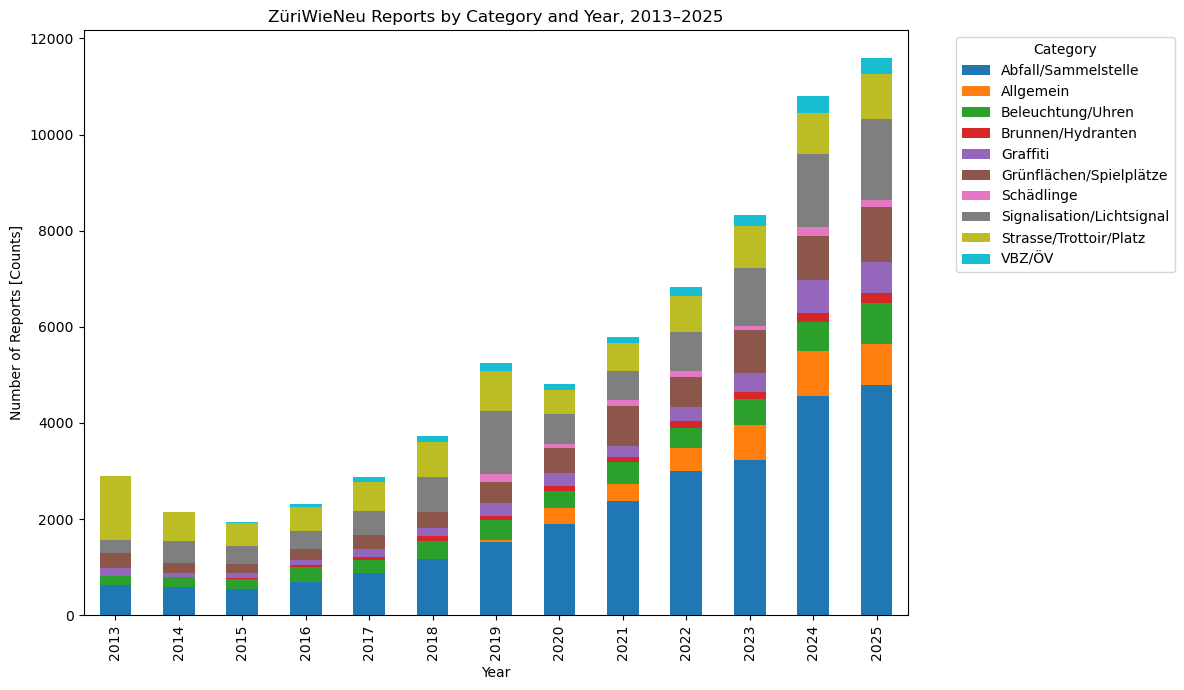

In [26]:
import matplotlib.pyplot as plt

category_counts_wide.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("ZüriWieNeu Reports by Category and Year, 2013–2025")
plt.xlabel("Year")
plt.ylabel("Number of Reports [Counts]")
plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/outputs/R2_StackedBar_Categories.png", bbox_inches="tight")
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of the stacked bar chart

The stacked bar chart shows how the total number of ZüriWieNeu reports is distributed across different report categories between 2013 and 2025.

Overall, the chart confirms across all categories. Some categories contribute much more strongly to the total number of reports than others.

The category **Abfall/Sammelstelle** represents a particularly large share of reports, especially in the later years. Other important categories include **Signalisation/Lichtsignal**, **Strasse/Trottoir/Platz**, **Grünflächen/Spielplätze**, and **Beleuchtung/Uhren**.

The chart also shows that some categories are smaller or appear more clearly only in later years. This may indicate changes in the way reports were categorized, changes in platform use, or shifts in the types of issues residents reported.

Because the chart includes all ten categories, it gives a complete overview of category development. However, it is visually quite dense.


In [24]:
category_shares_wide = category_counts_wide.div(
    category_counts_wide.sum(axis=1),
    axis=0
) * 100

category_shares_wide


service_name,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,Brunnen/Hydranten,Graffiti,Grünflächen/Spielplätze,Schädlinge,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
year,,,,,,,,,,
2013,21.992416,0.000000,6.308170,0.000000,5.653223,10.754912,0.000000,9.513961,45.777318,0.000000
2014,27.349229,0.000000,9.864423,0.000000,3.646564,10.331931,0.000000,20.944367,27.863488,0.000000
2015,27.637674,0.000000,10.962429,0.823469,5.970149,9.881626,0.000000,18.733917,24.909933,1.080803
2016,29.605548,0.000000,13.870828,1.560468,5.201560,9.839619,0.000000,15.908106,21.413091,2.600780
2017,30.359010,0.000000,9.445800,2.335308,5.925410,10.352039,0.000000,17.113977,20.878355,3.590101
2018,31.444683,0.000000,10.177229,2.577873,4.645542,8.592911,0.000000,19.871106,19.226638,3.464017
2019,29.143620,0.534045,8.086973,1.678428,5.206943,8.201411,3.318711,24.985695,15.887850,2.956323
2020,39.421075,7.184506,7.142857,2.061641,5.935027,10.620575,1.811745,13.036235,10.162432,2.623907
2021,40.930313,6.346187,7.712260,1.971295,3.838838,14.542625,1.902127,10.513574,10.150441,2.092340


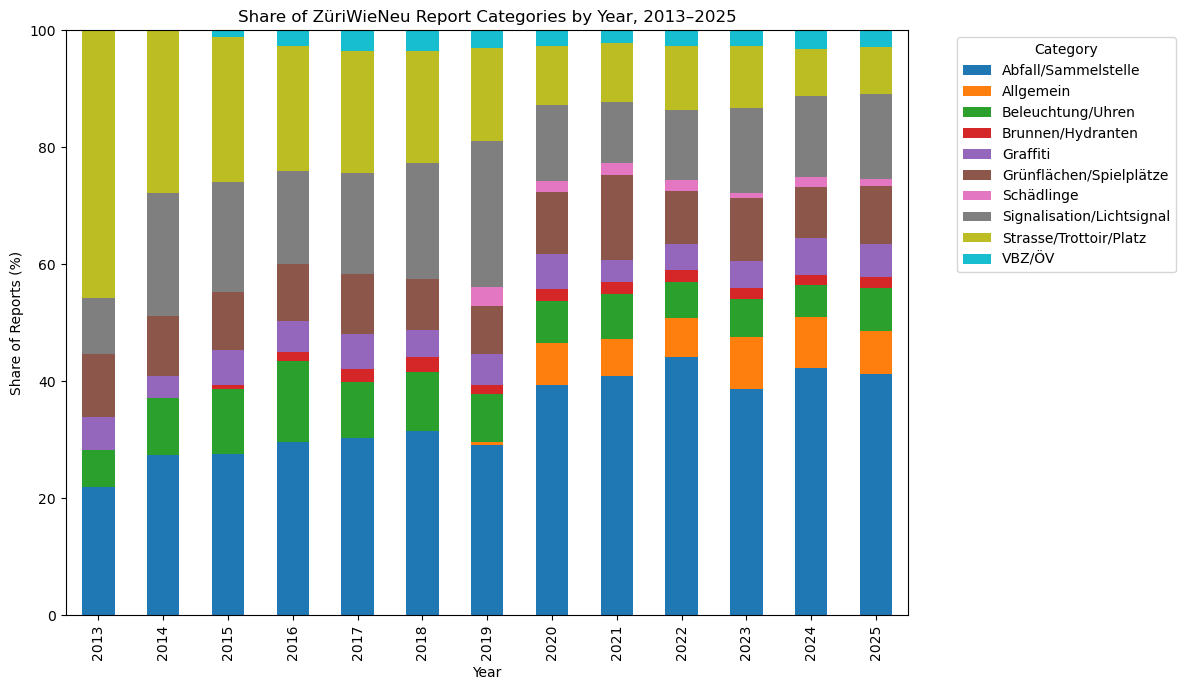

In [27]:
import matplotlib.pyplot as plt

category_shares_wide.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Share of ZüriWieNeu Report Categories by Year, 2013–2025")
plt.xlabel("Year")
plt.ylabel("Share of Reports (%)")

plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("/Users/laumagoldmann/Desktop/SDS210_IndividualProject/outputs/R2_ShareCategories_Stacked.png", bbox_inches="tight")
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Interpretation of category shares

The 100% stacked bar chart shows how the relative composition of ZüriWieNeu report categories changed between 2013 and 2025.

Compared to the previous stacked bar chart with absolute counts, this visualization focuses on proportions rather than total report numbers. This makes it easier to see whether certain categories became more or less important within the overall reporting activity.

The chart shows that some categories make up a consistently large share of reports over time, especially **Abfall/Sammelstelle**, **Signalisation/Lichtsignal**, and **Strasse/Trottoir/Platz**. At the same time, the relative importance of categories changes between years. This suggests that the growth in ZüriWieNeu reports was not only caused by a general increase across all categories, but also involved shifts in the types of issues being reported.

The share-based view is important because it separates changes in category composition from the overall increase in report volume.

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Conclusion

This notebook analysed how the composition of ZüriWieNeu report categories changed between 2013 and 2025.

The absolute stacked bar chart showed that the total number of reports increased strongly over time, confirming the general trend identified in Research Question 1. It also showed that this increase was driven mainly by several large categories, especially **Abfall/Sammelstelle**, **Signalisation/Lichtsignal**, **Strasse/Trottoir/Platz**, **Grünflächen/Spielplätze**, and **Beleuchtung/Uhren**.

The 100% stacked bar chart added a relative perspective by showing the share of each category within every year. This made it possible to analyse category composition independently of the overall growth in report numbers. The results suggest that some categories remained consistently important, while others changed in their relative importance over time.

Overall, the analysis shows that ZüriWieNeu reporting activity did not only increase in quantity, but also changed in composition. This means that residents' use of the platform developed both in terms of how often reports were submitted and in terms of what kinds of urban problems were reported.